# Lab 10 - Aprendizaje Semi-Supervisado
## Grupo 02: Co-Training
Idea central: uso de multiples vistas independientes del dataset 
Temas: 
- Supuesto de independencia condicional 
- Feature splitting 
- Algoritmos: Co-training con clasificadores distintos (ej. Naive Bayes + SVM) 

**Dataset:** Mushroom Classification (UCI / Kaggle)  
**Fuente:** https://www.kaggle.com/datasets/uciml/mushroom-classification  

In [1]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12

print('Librerías cargadas correctamente')

c:\Users\David\Documents\2026\S1\MINERIADATOS\Lab10-md\md\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Librerías cargadas correctamente


## 2. Carga del Dataset

In [2]:
df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "uciml/mushroom-classification",
    "mushrooms.csv",
)

print(f'Dataset cargado: {df.shape[0]} filas × {df.shape[1]} columnas')
df.head()

100%|██████████| 365k/365k [00:00<00:00, 645kB/s]

Dataset cargado: 8124 filas × 23 columnas


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


## 3. Descripción general del dataset

In [3]:

print('INFORMACIÓN GENERAL DEL DATASET')

print(f'  Filas    : {df.shape[0]:,}')
print(f'  Columnas : {df.shape[1]}')
print(f'  Variable objetivo: class (p = venenoso, e = comestible)')
print()
print('Tipos de datos:')
print(df.dtypes.value_counts())

INFORMACIÓN GENERAL DEL DATASET
  Filas    : 8,124
  Columnas : 23
  Variable objetivo: class (p = venenoso, e = comestible)

Tipos de datos:
str    23
Name: count, dtype: int64


In [4]:
# Descripción de columnas con sus valores únicos
descripcion = pd.DataFrame({
    'Tipo': df.dtypes,
    'Valores únicos': df.nunique(),
    'Valores nulos': df.isnull().sum(),
    '% nulos': (df.isnull().sum() / len(df) * 100).round(2),
    'Valores posibles': df.apply(lambda col: sorted(col.unique().tolist()))
})

print('\nResumen de columnas:')
descripcion


Resumen de columnas:


,Tipo,Valores únicos,Valores nulos,% nulos,Valores posibles
class,str,2,0,0.0,"[e, p]"
cap-shape,str,6,0,0.0,"[b, c, f, k, s, x]"
cap-surface,str,4,0,0.0,"[f, g, s, y]"
cap-color,str,10,0,0.0,"[b, c, e, g, n, p, r, u, w, y]"
bruises,str,2,0,0.0,"[f, t]"
odor,str,9,0,0.0,"[a, c, f, l, m, n, p, s, y]"
gill-attachment,str,2,0,0.0,"[a, f]"
gill-spacing,str,2,0,0.0,"[c, w]"
gill-size,str,2,0,0.0,"[b, n]"
gill-color,str,12,0,0.0,"[b, e, g, h, k, n, o, p, r, u, w, y]"


### 3.1 Estadísticas descriptivas


In [5]:
# Estadísticas descriptivas para variables categóricas
print('Estadísticas descriptivas (variables categóricas):')
df.describe(include='object')

Estadísticas descriptivas (variables categóricas):


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
count,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,...,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124
unique,2,6,4,10,2,9,2,2,2,12,...,4,9,9,1,4,3,5,9,6,7
top,e,x,y,n,f,n,f,c,b,b,...,s,w,w,p,w,o,p,w,v,d
freq,4208,3656,3244,2284,4748,3528,7914,6812,5612,1728,...,4936,4464,4384,8124,7924,7488,3968,2388,4040,3148


In [6]:
# Moda por columna
modas = df.mode().iloc[0]
print('Moda (valor más frecuente) por columna:')
print(modas.to_frame(name='Moda').T)

Moda (valor más frecuente) por columna:
     class cap-shape cap-surface cap-color bruises odor gill-attachment  \
Moda     e         x           y         n       f    n               f   

     gill-spacing gill-size gill-color  ... stalk-surface-below-ring  \
Moda            c         b          b  ...                        s   

     stalk-color-above-ring stalk-color-below-ring veil-type veil-color  \
Moda                      w                      w         p          w   

     ring-number ring-type spore-print-color population habitat  
Moda           o         p                 w          v       d  

[1 rows x 23 columns]


## 4. Análisis de la variable objetivo: class

In [7]:
# Distribución de clases
class_counts = df['class'].value_counts()
class_labels = {'p': 'Venenoso (p)', 'e': 'Comestible (e)'}
class_counts.index = class_counts.index.map(class_labels)

print('Distribución de clases:')
print(class_counts.to_frame('Cantidad').assign(Porcentaje=lambda x: (x['Cantidad'] / len(df) * 100).round(2)))
print()
print(f'Balance de clases: {class_counts.min() / class_counts.max():.3f}  (1.0 = perfecto)')

Distribución de clases:
                Cantidad  Porcentaje
class                               
Comestible (e)      4208        51.8
Venenoso (p)        3916        48.2

Balance de clases: 0.931  (1.0 = perfecto)


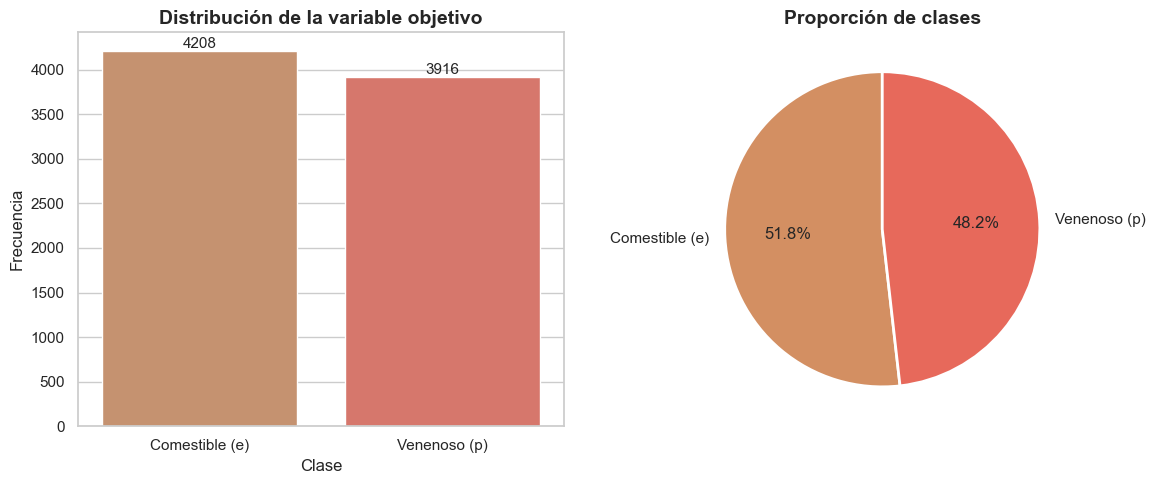

Figura 1. Distribución de la variable objetivo (class).


In [8]:
# Gráfico de distribución de clases — Seaborn + Plotly
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Barplot
sns.countplot(data=df, x='class', palette=["#d38f62", "#e7695b"],
              order=['e', 'p'], ax=axes[0])
axes[0].set_title('Distribución de la variable objetivo', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Clase')
axes[0].set_ylabel('Frecuencia')
axes[0].set_xticklabels(['Comestible (e)', 'Venenoso (p)'])
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{int(bar.get_height())}', ha='center', fontsize=11)

# Pie chart
axes[1].pie(
    class_counts.values,
    labels=class_counts.index,
    autopct='%1.1f%%',
    colors=["#d38f62", "#e7695b"],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Proporción de clases', fontsize=14, fontweight='bold')

plt.tight_layout()
#plt.savefig('distribucion_clases.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura 1. Distribución de la variable objetivo (class).')

## 5. Distribución de variables categóricas

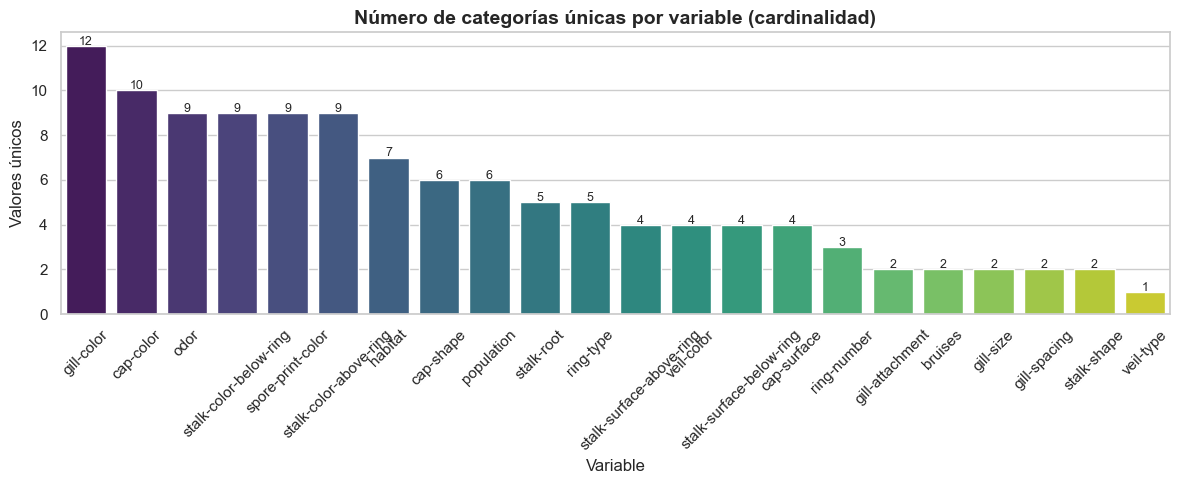

Figura 2. Cardinalidad (número de valores únicos) por variable.


In [9]:
# Frecuencia de cada categoría por variable — heatmap de cardinalidad
cardinalidad = df.nunique().sort_values(ascending=False).drop('class')

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(x=cardinalidad.index, y=cardinalidad.values,
            palette='viridis', ax=ax)
ax.set_title('Número de categorías únicas por variable (cardinalidad)', fontsize=14, fontweight='bold')
ax.set_xlabel('Variable')
ax.set_ylabel('Valores únicos')
ax.tick_params(axis='x', rotation=45)
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            str(int(bar.get_height())), ha='center', fontsize=9)
plt.tight_layout()
#plt.savefig('cardinalidad_variables.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura 2. Cardinalidad (número de valores únicos) por variable.')

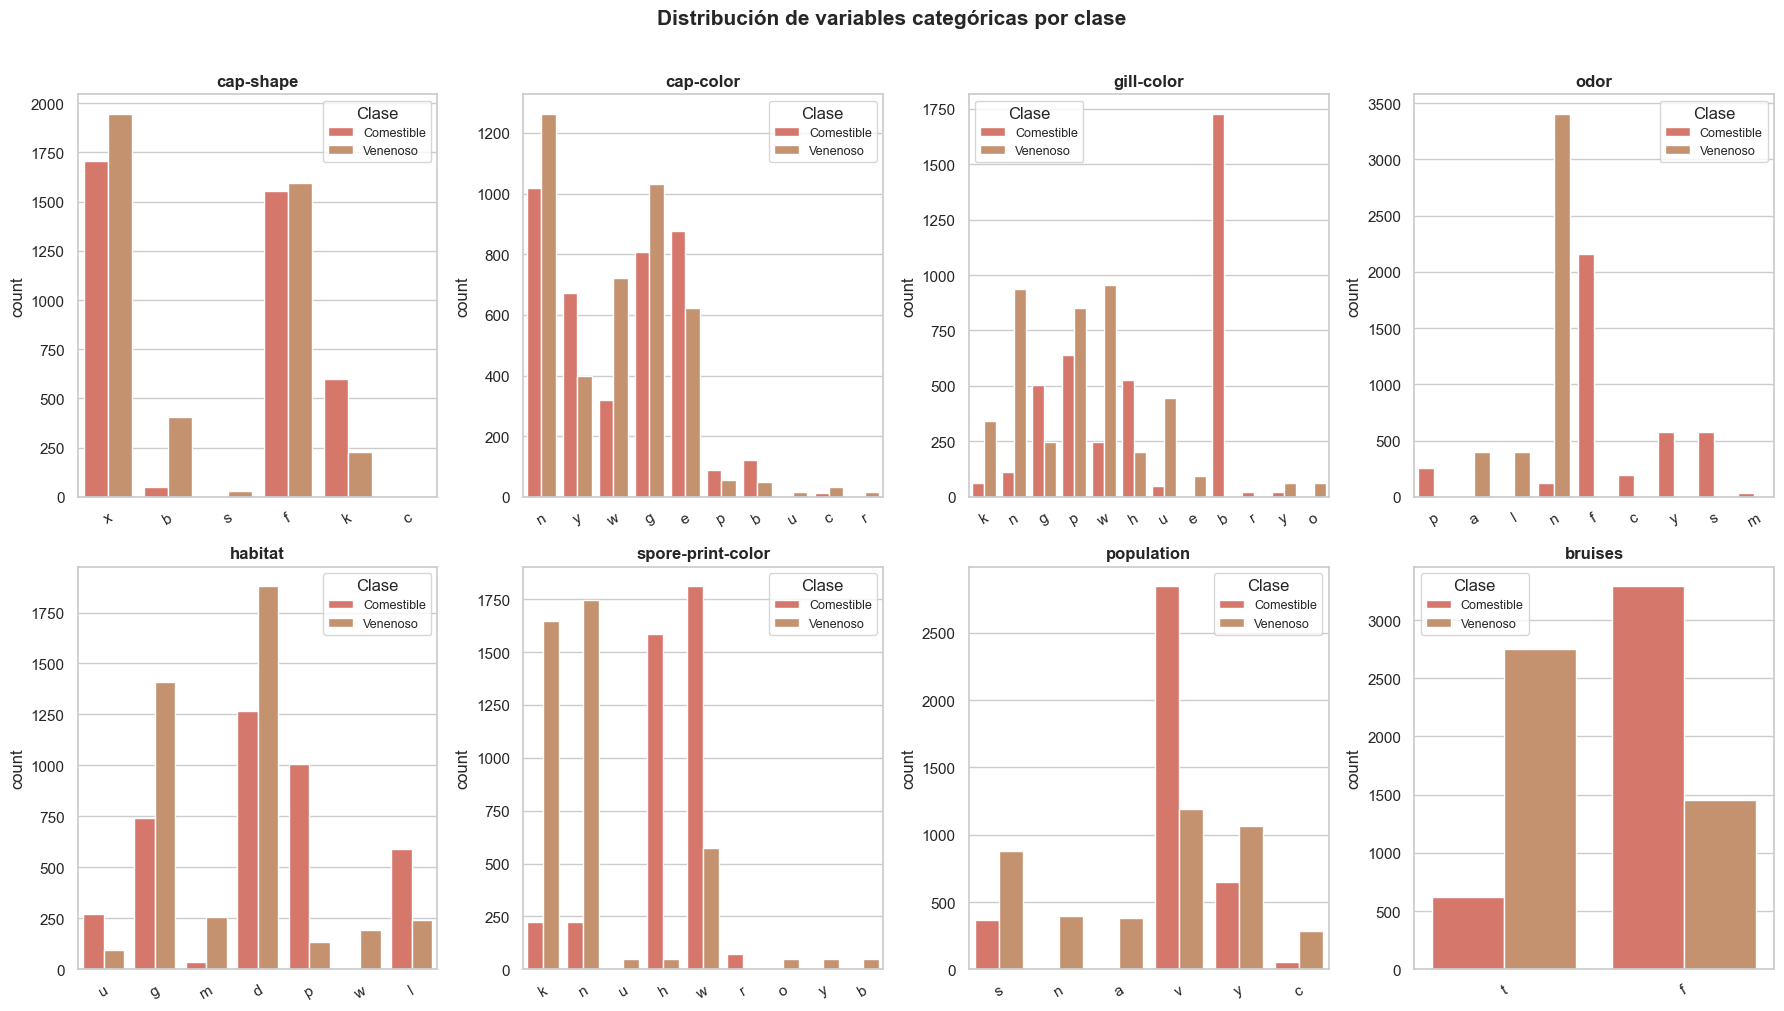

Figura 3. Distribución de 8 variables categóricas clave segmentadas por clase objetivo.


In [10]:
# Distribución de las primeras 8 variables más importantes vs clase objetivo — Seaborn
features_plot = ['cap-shape', 'cap-color', 'gill-color', 'odor',
                 'habitat', 'spore-print-color', 'population', 'bruises']

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(features_plot):
    sns.countplot(data=df, x=col, hue='class',
                  palette={'e': '#d38f62', 'p': '#e7695b'}, 
                  ax=axes[i])
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(title='Clase', labels=['Comestible', 'Venenoso'], fontsize=9)

plt.suptitle('Distribución de variables categóricas por clase', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
#plt.savefig('distribucion_variables_por_clase.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura 3. Distribución de 8 variables categóricas clave segmentadas por clase objetivo.')

## 6. Análisis de valores nulos y calidad del dato

In [11]:
# El dataset Mushroom tiene una columna especial: 'stalk-root' con '?' como missing
# Detectamos y reportamos esto

missing_explicit = (df == '?').sum()
missing_explicit = missing_explicit[missing_explicit > 0]

print('Valores nulos convencionales (NaN):', df.isnull().sum().sum())
print()
if len(missing_explicit) > 0:
    print('Columnas con "?" (missing implícito):')
    for col, count in missing_explicit.items():
        pct = count / len(df) * 100
        print(f'  {col}: {count} registros ({pct:.1f}%)')
else:
    print('No se encontraron valores "?" en el dataset.')

Valores nulos convencionales (NaN): 0

Columnas con "?" (missing implícito):
  stalk-root: 2480 registros (30.5%)


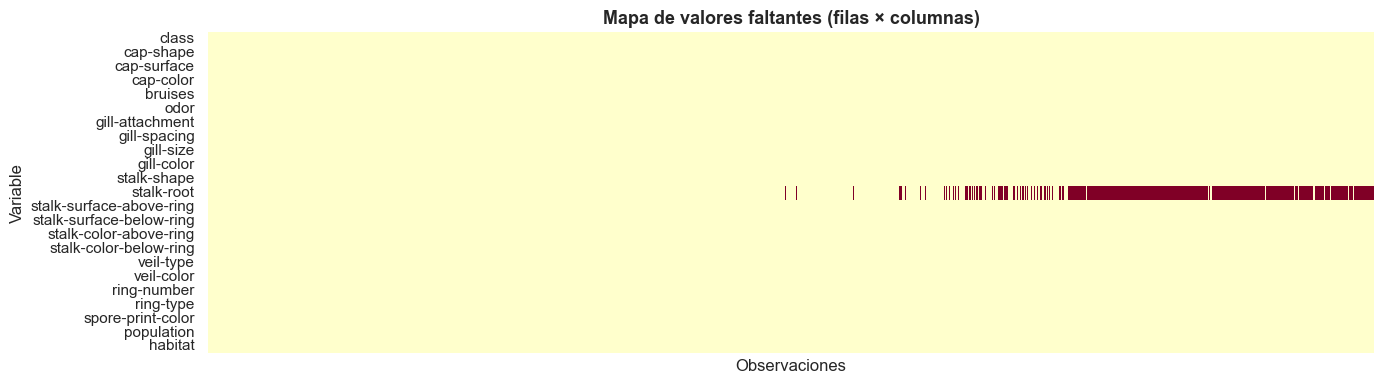

Figura 4. Mapa de valores faltantes. Amarillo/rojo indica ausencia de dato.


In [12]:
# Visualización de missing values con heatmap (Seaborn)
# Reemplazamos '?' por NaN para visualizar correctamente
df_viz = df.replace('?', np.nan)

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(df_viz.isnull().T,
            cmap='YlOrRd', cbar=False,
            yticklabels=True, xticklabels=False, ax=ax)
ax.set_title('Mapa de valores faltantes (filas × columnas)', fontsize=13, fontweight='bold')
ax.set_xlabel('Observaciones')
ax.set_ylabel('Variable')
plt.tight_layout()
#plt.savefig('missing_values_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura 4. Mapa de valores faltantes. Amarillo/rojo indica ausencia de dato.')

## 7. Análisis de la variable odor — predictora clave

In [13]:
# 'odor' es conocida por ser altamente discriminativa en este dataset
odor_map = {
    'a': 'almendra', 'l': 'anís', 'c': 'creosota',
    'y': 'pescado', 'f': 'fétido', 'm': 'a tierra',
    'n': 'ninguno', 'p': 'picante', 's': 'a especias'
}

df_odor = df.copy()
df_odor['odor_label'] = df_odor['odor'].map(odor_map)

odor_class = df_odor.groupby(['odor_label', 'class']).size().unstack(fill_value=0)
odor_class.columns = ['Comestible', 'Venenoso']
odor_class = odor_class.sort_values('Venenoso', ascending=False)

fig = px.bar(
    odor_class.reset_index(), x='odor_label',
    y=['Comestible', 'Venenoso'],
    barmode='group',
    color_discrete_map={'Comestible': '#d38f62', 'Venenoso': '#e7695b'},
    title='Distribución de clases según tipo de olor (odor)',
    labels={'odor_label': 'Olor', 'value': 'Frecuencia', 'variable': 'Clase'}
)
fig.update_layout(plot_bgcolor='white', title_font_size=15)
fig.show()
print('Figura 5. La variable odor es altamente discriminativa: olores como fétido, a especias y creosota son exclusivos de hongos venenosos.')

Figura 5. La variable odor es altamente discriminativa: olores como fétido, a especias y creosota son exclusivos de hongos venenosos.


## 8. Correlación entre variables (Cramér's V)

In [14]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    """Calcula el coeficiente V de Cramér entre dos variables categóricas."""
    contingency = pd.crosstab(x, y)
    chi2 = chi2_contingency(contingency)[0]
    n = contingency.sum().sum()
    r, k = contingency.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

# Calculamos Cramér's V para todas las columnas vs la variable clase
cols = [c for c in df.columns if c != 'class']
cramers_vs_class = {}
for col in cols:
    try:
        cramers_vs_class[col] = cramers_v(df[col], df['class'])
    except Exception:
        cramers_vs_class[col] = np.nan

cramers_series = pd.Series(cramers_vs_class).sort_values(ascending=False)

print('Asociación de cada variable con la clase objetivo (Cramér\'s V):')
print(cramers_series.round(3).to_frame('Cramér\'s V'))

Asociación de cada variable con la clase objetivo (Cramér's V):
                          Cramér's V
odor                           0.971
spore-print-color              0.753
gill-color                     0.681
ring-type                      0.603
stalk-surface-above-ring       0.588
stalk-surface-below-ring       0.575
gill-size                      0.540
stalk-color-above-ring         0.525
stalk-color-below-ring         0.515
bruises                        0.501
population                     0.487
habitat                        0.440
stalk-root                     0.407
gill-spacing                   0.348
cap-shape                      0.246
cap-color                      0.218
ring-number                    0.215
cap-surface                    0.197
veil-color                     0.153
gill-attachment                0.128
stalk-shape                    0.102
veil-type                        NaN


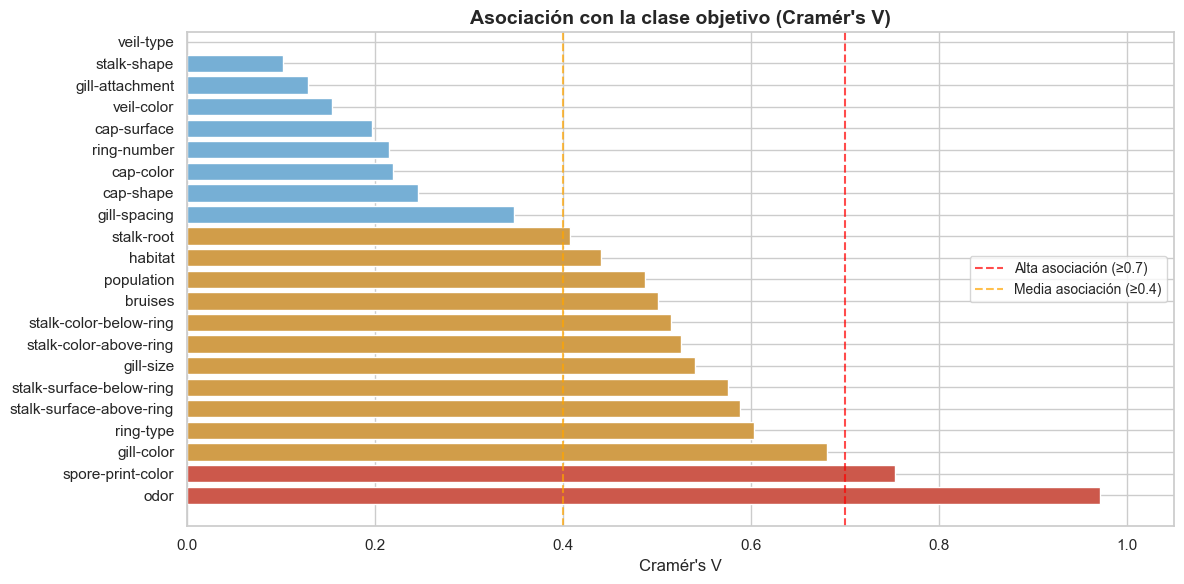

Figura 6. Asociación entre variables predictoras y la clase objetivo medida con Cramér's V. Rojo = alta asociación.


In [15]:
# Visualización — Barplot de Cramér's V vs clase
fig, ax = plt.subplots(figsize=(12, 6))
colors = ["#cc584b" if v >= 0.7 else "#d19d49" if v >= 0.4 else "#76afd5"
          for v in cramers_series.values]

bars = ax.barh(cramers_series.index, cramers_series.values, color=colors)
ax.axvline(x=0.7, color='red', linestyle='--', alpha=0.7, label='Alta asociación (≥0.7)')
ax.axvline(x=0.4, color='orange', linestyle='--', alpha=0.7, label='Media asociación (≥0.4)')
ax.set_title("Asociación con la clase objetivo (Cramér's V)", fontsize=14, fontweight='bold')
ax.set_xlabel("Cramér's V")
ax.set_xlim(0, 1.05)
ax.legend(fontsize=10)
plt.tight_layout()
#plt.savefig('cramers_v_vs_clase.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura 6. Asociación entre variables predictoras y la clase objetivo medida con Cramér's V. Rojo = alta asociación.")

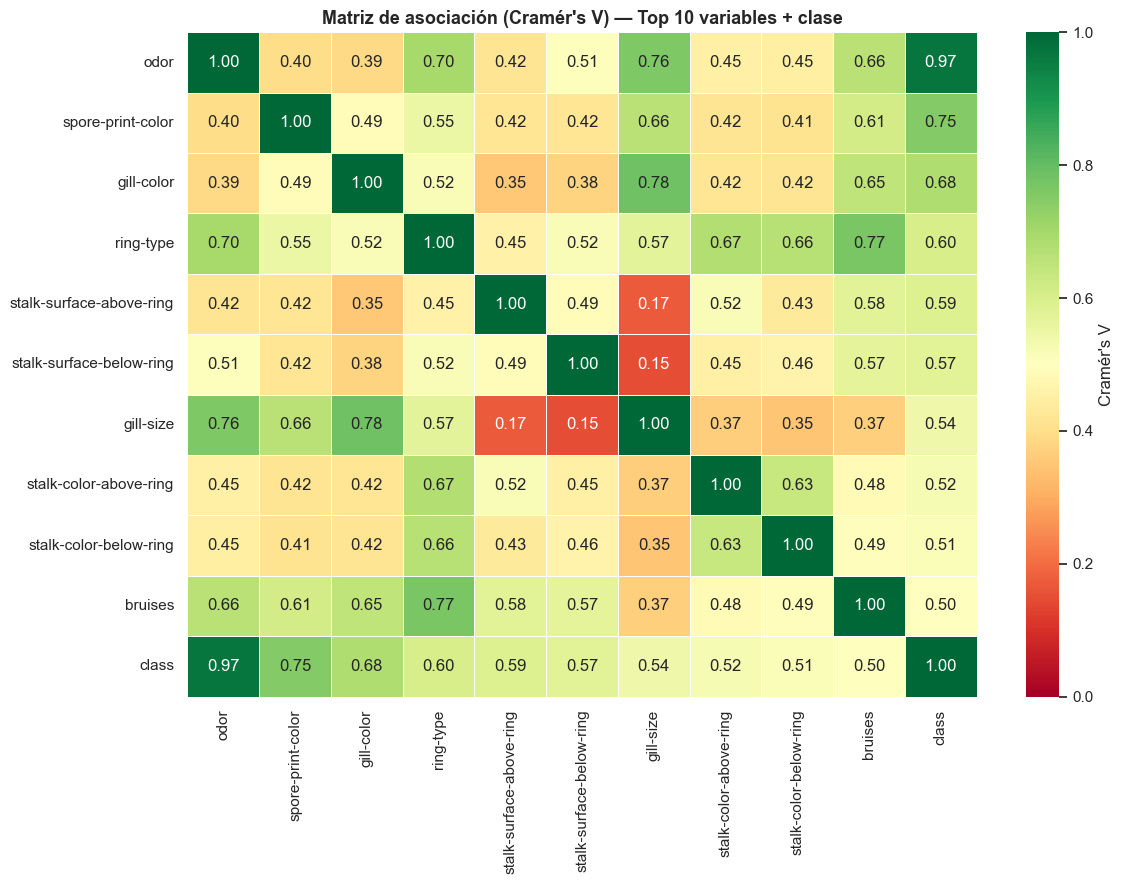

Figura 7. Heatmap de Cramér's V entre las 10 variables más predictivas y la clase objetivo.


In [16]:
# Heatmap de Cramér's V entre todas las variables (matriz completa)
# Computacionalmente costoso — usamos un subconjunto de las 10 más asociadas
top_features = cramers_series.head(10).index.tolist() + ['class']
df_top = df[top_features]

all_cols = df_top.columns.tolist()
matrix = pd.DataFrame(index=all_cols, columns=all_cols, dtype=float)

for c1 in all_cols:
    for c2 in all_cols:
        if c1 == c2:
            matrix.loc[c1, c2] = 1.0
        elif pd.isna(matrix.loc[c1, c2]):
            v = cramers_v(df_top[c1], df_top[c2])
            matrix.loc[c1, c2] = v
            matrix.loc[c2, c1] = v

matrix = matrix.astype(float)

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(matrix, dtype=bool), k=1)
sns.heatmap(matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=0, vmax=1, linewidths=0.5,
            ax=ax, cbar_kws={'label': "Cramér's V"})
ax.set_title("Matriz de asociación (Cramér's V) — Top 10 variables + clase",
             fontsize=13, fontweight='bold')
plt.tight_layout()
#plt.savefig('heatmap_cramers_v.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura 7. Heatmap de Cramér's V entre las 10 variables más predictivas y la clase objetivo.")

## 9. Análisis interactivo con Plotly — Distribución general de variables

In [17]:
# Sunburst interactivo: habitat → class
df_sun = df.copy()

habitat_map = {
    'g': 'Pasto', 'l': 'Hojas', 'm': 'Pradera',
    'p': 'Caminos', 'u': 'Urbano', 'w': 'Desperdicio', 'd': 'Bosque'
}
class_map = {'p': 'Venenoso', 'e': 'Comestible'}
df_sun['habitat_label'] = df_sun['habitat'].map(habitat_map)
df_sun['class_label'] = df_sun['class'].map(class_map)

fig = px.sunburst(
    df_sun,
    path=['habitat_label', 'class_label'],
    color='class_label',
    color_discrete_map={'Comestible': '#d38f62', 'Venenoso': '#e7695b'},
    title='Distribución de hongos por hábitat y clase'
)
fig.update_layout(title_font_size=15)
fig.show()
print('Figura 8. Sunburst interactivo: composición de clases dentro de cada hábitat.')

Figura 8. Sunburst interactivo: composición de clases dentro de cada hábitat.


## 10. Preprocesamiento básico

In [18]:
from sklearn.preprocessing import LabelEncoder

df_clean = df.copy()

# 1. Reemplazar '?' por NaN y rellenar con la moda de la columna
df_clean = df_clean.replace('?', np.nan)
for col in df_clean.columns:
    if df_clean[col].isnull().sum() > 0:
        moda = df_clean[col].mode()[0]
        df_clean[col].fillna(moda, inplace=True)
        print(f'Columna "{col}": {df[col].eq("?").sum()} valores faltantes → imputados con moda ("{moda}")')

# 2. Label Encoding de todas las columnas categóricas
le = LabelEncoder()
df_encoded = df_clean.apply(le.fit_transform)

print(f'\nDataset preprocesado: {df_encoded.shape}')
print('Primeras filas del dataset codificado:')
df_encoded.head()

Columna "stalk-root": 2480 valores faltantes → imputados con moda ("b")

Dataset preprocesado: (8124, 23)
Primeras filas del dataset codificado:


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,1,5,2,4,1,6,1,0,1,4,...,2,7,7,0,2,1,4,2,3,5
1,0,5,2,9,1,0,1,0,0,4,...,2,7,7,0,2,1,4,3,2,1
2,0,0,2,8,1,3,1,0,0,5,...,2,7,7,0,2,1,4,3,2,3
3,1,5,3,8,1,6,1,0,1,5,...,2,7,7,0,2,1,4,2,3,5
4,0,5,2,3,0,5,1,1,0,4,...,2,7,7,0,2,1,0,3,0,1


In [19]:
# Separar X e y
X = df_encoded.drop(columns=['class'])
y = df_encoded['class']  # 0 = comestible, 1 = venenoso

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'\nDistribución en y codificada:\n{y.value_counts()}')

# Guardamos para uso posterior por el resto del equipo
X.to_csv('X_mushroom.csv', index=False)
y.to_csv('y_mushroom.csv', index=False)
print('\n X_mushroom.csv e y_mushroom.csv guardados correctamente.')

X shape: (8124, 22)
y shape: (8124,)

Distribución en y codificada:
class
0    4208
1    3916
Name: count, dtype: int64

 X_mushroom.csv e y_mushroom.csv guardados correctamente.


## Fase 2 — Selección y Análisis del Dataset


### Análisis y Exploración de Datos (EDA)
#### 2.1 Dimensionalidad y tipos de variables

In [20]:
# 2.1 Dimensionalidad y tipos de variables

print("  DIMENSIONALIDAD Y TIPOS DE VARIABLES")
print(f"  Filas        : {df.shape[0]:,}")
print(f"  Columnas     : {df.shape[1]}")
print(f"  Características (X): {df.shape[1] - 1}")
print(f"  Variable objetivo : class")
print()

# Tipos semánticos
todas_cat = df.select_dtypes(include='object').columns.tolist()
print(f"  Tipo de datos   : 100 % categóricas nominales ({len(todas_cat)} columnas)")
print()

# Cardinalidad por variable
card = df.drop(columns='class').nunique().sort_values()
print("  Cardinalidad por variable (valores únicos):")
print(f"    Mínima : {card.min()}  → {card.idxmin()}")
print(f"    Máxima : {card.max()} → {card.idxmax()}")
print()

# Variable constante
constantes = [c for c in df.columns if df[c].nunique() == 1]
print(f"  Variables constantes (1 único valor): {constantes}")
print("  → 'veil-type' será eliminada en el preprocesamiento.")

  DIMENSIONALIDAD Y TIPOS DE VARIABLES
  Filas        : 8,124
  Columnas     : 23
  Características (X): 22
  Variable objetivo : class

  Tipo de datos   : 100 % categóricas nominales (23 columnas)

  Cardinalidad por variable (valores únicos):
    Mínima : 1  → veil-type
    Máxima : 12 → gill-color

  Variables constantes (1 único valor): ['veil-type']
  → 'veil-type' será eliminada en el preprocesamiento.


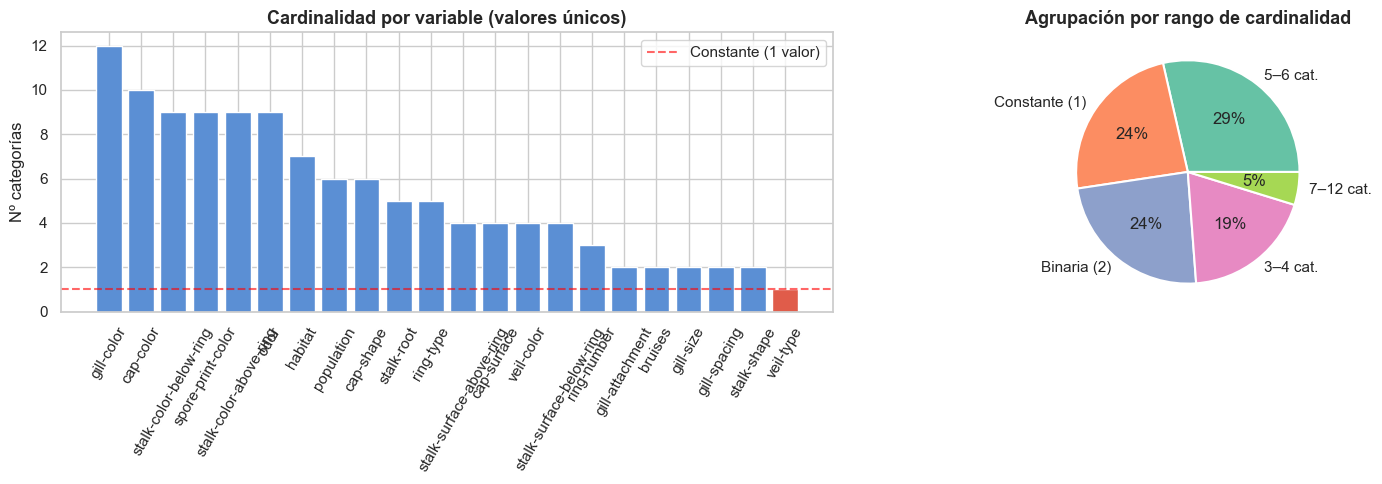

Figura A. Cardinalidad de cada variable. En rojo: variable constante (veil-type).


In [21]:
# Visualización: cardinalidad de todas las variables
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Barplot cardinalidad
card_all = df.drop(columns='class').nunique().sort_values(ascending=False)
colors_card = ['#e05c4a' if v == 1 else '#5b8fd4' for v in card_all.values]
axes[0].bar(card_all.index, card_all.values, color=colors_card)
axes[0].set_title('Cardinalidad por variable (valores únicos)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Nº categorías')
axes[0].tick_params(axis='x', rotation=60)
axes[0].axhline(1, color='red', linestyle='--', alpha=0.6, label='Constante (1 valor)')
axes[0].legend()

# Pie: distribución de cardinalidad agrupada
bins = [1, 2, 4, 6, 10, 15]
labels_bins = ['Constante (1)', 'Binaria (2)', '3–4 cat.', '5–6 cat.', '7–12 cat.']
card_grouped = pd.cut(card_all, bins=bins, labels=labels_bins, right=True).value_counts()
axes[1].pie(card_grouped.values, labels=card_grouped.index, autopct='%1.0f%%',
            colors=sns.color_palette('Set2', len(card_grouped)),
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Agrupación por rango de cardinalidad', fontsize=13, fontweight='bold')

plt.tight_layout()
#plt.savefig('cardinalidad_detalle.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura A. Cardinalidad de cada variable. En rojo: variable constante (veil-type).')

#### 2.2 Balance de clases y análisis estadístico detallado

In [22]:
from scipy.stats import chi2_contingency

# Balance de clases detallado
cnt = df['class'].value_counts()
ratio = cnt.min() / cnt.max()

print("BALANCE DE CLASES")
print(f"  Comestible (e) : {cnt.get('e', 0):,}  ({cnt.get('e', 0)/len(df)*100:.1f} %)")
print(f"  Venenoso   (p) : {cnt.get('p', 0):,}  ({cnt.get('p', 0)/len(df)*100:.1f} %)")
print(f"  Ratio minority/majority : {ratio:.3f}")
print()
if ratio >= 0.8:
    print("  → Dataset BALANCEADO (ratio ≥ 0.8). No se requiere oversampling/undersampling.")
else:
    print("  → Dataset DESBALANCEADO. Considerar SMOTE o ajuste de pesos.")

# Chi-cuadrado para cada variable vs clase
print()
print("PRUEBAS CHI-CUADRADO (variable vs. clase objetivo)")
print(f"{'Variable':<30} {'Chi2':>10} {'p-value':>12} {'Asociación':>15}")
print("")

resultados_chi2 = {}
for col in df.columns:
    if col == 'class':
        continue
    tabla = pd.crosstab(df[col], df['class'])
    chi2_val, p_val, dof, _ = chi2_contingency(tabla)
    resultados_chi2[col] = {'chi2': chi2_val, 'p_value': p_val, 'dof': dof}
    nivel = "*** Alta" if p_val < 0.001 else "** Media" if p_val < 0.01 else "* Baja" if p_val < 0.05 else "NS"
    print(f"  {col:<28} {chi2_val:>10.1f} {p_val:>12.2e} {nivel:>15}")

df_chi2 = pd.DataFrame(resultados_chi2).T.sort_values('chi2', ascending=False)
print()
print(f"  Todas las variables con p < 0.001 son estadísticamente significativas respecto a la clase.")

BALANCE DE CLASES
  Comestible (e) : 4,208  (51.8 %)
  Venenoso   (p) : 3,916  (48.2 %)
  Ratio minority/majority : 0.931

  → Dataset BALANCEADO (ratio ≥ 0.8). No se requiere oversampling/undersampling.

PRUEBAS CHI-CUADRADO (variable vs. clase objetivo)
Variable                             Chi2      p-value      Asociación

  cap-shape                         489.9    1.20e-103        *** Alta
  cap-surface                       315.0     5.52e-68        *** Alta
  cap-color                         387.6     6.06e-78        *** Alta
  bruises                          2041.4     0.00e+00        *** Alta
  odor                             7659.7     0.00e+00        *** Alta
  gill-attachment                   134.0     5.50e-31        *** Alta
  gill-spacing                      984.1    5.02e-216        *** Alta
  gill-size                        2366.8     0.00e+00        *** Alta
  gill-color                       3765.7     0.00e+00        *** Alta
  stalk-shape                    

In [23]:
from sklearn.feature_selection import mutual_info_classif

# Mutual Information usando el dataset codificado (sin veil-type)
X_mi = df_encoded.drop(columns=['class', 'veil-type'], errors='ignore')
y_mi = df_encoded['class']

mi_scores = mutual_info_classif(X_mi, y_mi, discrete_features=True, random_state=42)
mi_series = pd.Series(mi_scores, index=X_mi.columns).sort_values(ascending=False)

print("INFORMACIÓN MUTUA (Mutual Information) - Variables vs. Clase")
print(f"{'Variable':<30} {'MI Score':>10}")
for feat, score in mi_series.items():
    bar = '█' * int(score * 30)
    print(f"  {feat:<28} {score:>8.4f}  {bar}")

print()
print(f"  Top 5 variables más informativas: {mi_series.head(5).index.tolist()}")

INFORMACIÓN MUTUA (Mutual Information) - Variables vs. Clase
Variable                         MI Score
  odor                           0.6280  ██████████████████
  spore-print-color              0.3332  █████████
  gill-color                     0.2890  ████████
  ring-type                      0.2204  ██████
  stalk-surface-above-ring       0.1974  █████
  stalk-surface-below-ring       0.1885  █████
  stalk-color-above-ring         0.1760  █████
  stalk-color-below-ring         0.1673  █████
  gill-size                      0.1595  ████
  population                     0.1400  ████
  bruises                        0.1333  ████
  habitat                        0.1087  ███
  stalk-root                     0.0934  ██
  gill-spacing                   0.0699  ██
  cap-shape                      0.0338  █
  ring-number                    0.0267  
  cap-color                      0.0250  
  cap-surface                    0.0198  
  veil-color                     0.0165  
  gill-attachment 

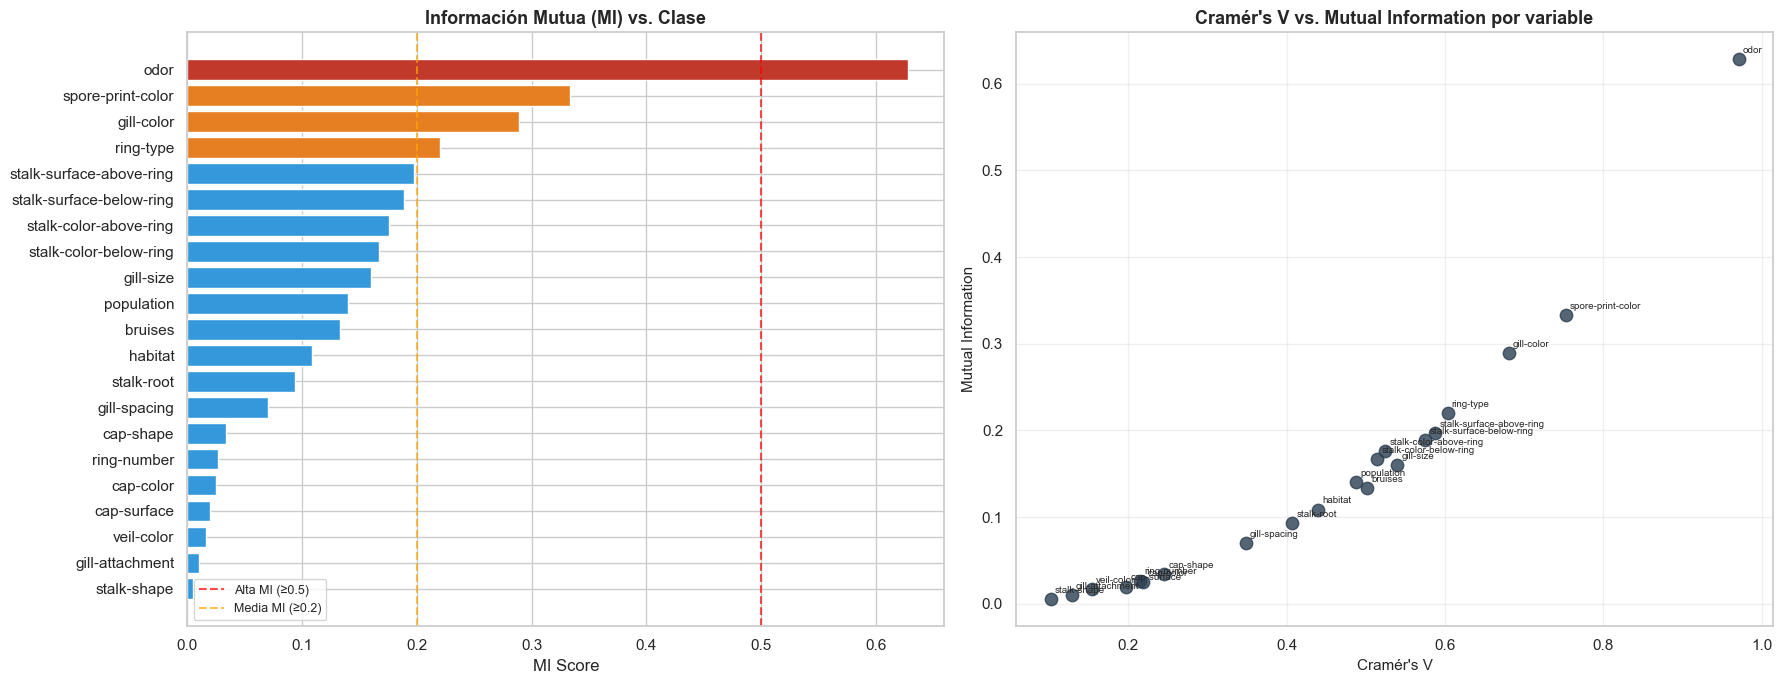

Figura B. Izquierda: MI Score por variable. Derecha: correlación entre Cramér's V y MI - ambas métricas son consistentes.


In [24]:
# Visualización comparativa: Cramér's V vs Mutual Information
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Barplot MI
colors_mi = ['#c0392b' if s >= 0.5 else '#e67e22' if s >= 0.2 else '#3498db'
             for s in mi_series.values]
axes[0].barh(mi_series.index[::-1], mi_series.values[::-1], color=colors_mi[::-1])
axes[0].axvline(0.5, color='red', linestyle='--', alpha=0.7, label='Alta MI (≥0.5)')
axes[0].axvline(0.2, color='orange', linestyle='--', alpha=0.7, label='Media MI (≥0.2)')
axes[0].set_title('Información Mutua (MI) vs. Clase', fontsize=13, fontweight='bold')
axes[0].set_xlabel('MI Score')
axes[0].legend(fontsize=9)

# Scatter Cramér's V vs MI (alineamos por nombre)
common = mi_series.index.intersection(cramers_series.index)
x_cv = cramers_series[common].values
y_mi_vals = mi_series[common].values

axes[1].scatter(x_cv, y_mi_vals, color='#2c3e50', s=80, alpha=0.8)
for feat in common:
    axes[1].annotate(feat, (cramers_series[feat], mi_series[feat]),
                     fontsize=7, ha='left', va='bottom',
                     xytext=(3, 3), textcoords='offset points')
axes[1].set_xlabel("Cramér's V", fontsize=11)
axes[1].set_ylabel('Mutual Information', fontsize=11)
axes[1].set_title("Cramér's V vs. Mutual Information por variable", fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
#plt.savefig('mi_vs_cramers.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura B. Izquierda: MI Score por variable. Derecha: correlación entre Cramér\'s V y MI - ambas métricas son consistentes.')

#### 2.3 Análisis de tasa de toxicidad por categoría — Variables más discriminativas

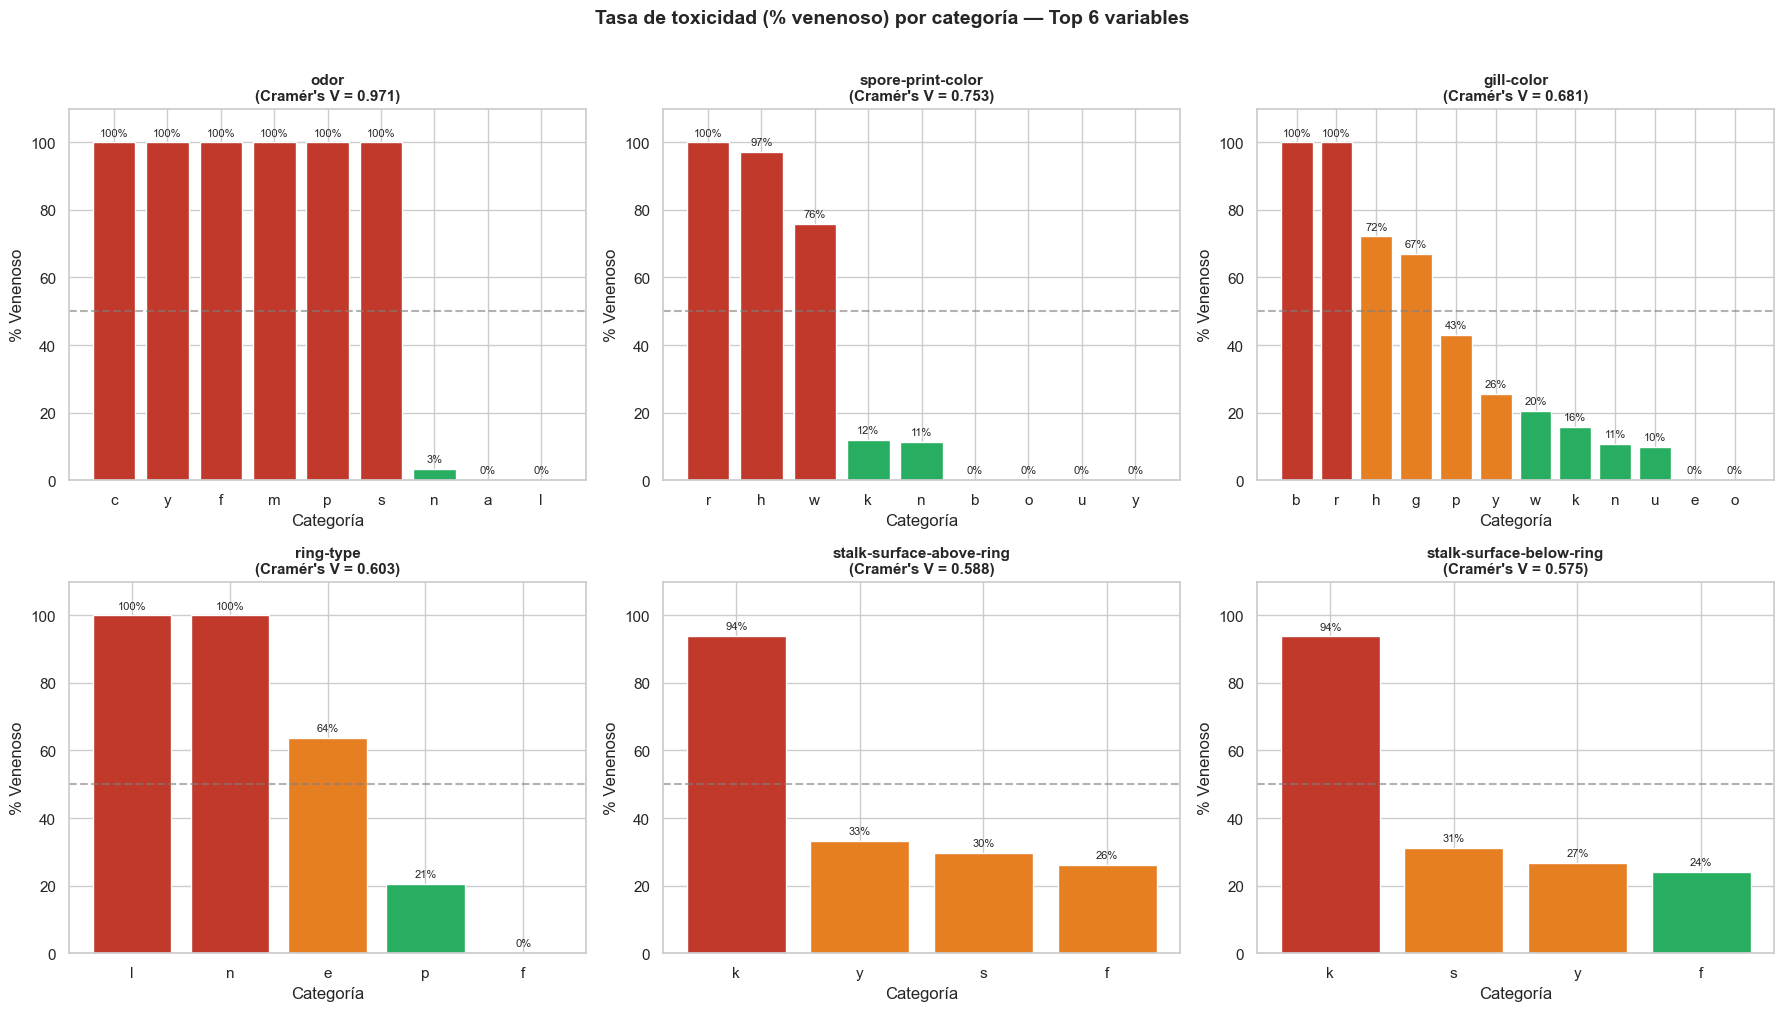

Figura C. Rojo = categoría mayoritariamente venenosa (≥75%), naranja = mixta, verde = mayoritariamente comestible.


In [25]:
# Tasa de toxicidad (% venenoso) por categoría en las top 6 variables
top6 = cramers_series.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(top6):
    tox_rate = (
        df.groupby(col)['class']
        .apply(lambda x: (x == 'p').sum() / len(x) * 100)
        .sort_values(ascending=False)
        .reset_index()
    )
    tox_rate.columns = ['categoria', 'pct_venenoso']

    colors = ['#c0392b' if v >= 75 else '#e67e22' if v >= 25 else '#27ae60'
              for v in tox_rate['pct_venenoso']]
    axes[i].bar(tox_rate['categoria'], tox_rate['pct_venenoso'], color=colors)
    axes[i].axhline(50, color='gray', linestyle='--', alpha=0.6)
    axes[i].set_title(f'{col}\n(Cramér\'s V = {cramers_series[col]:.3f})',
                      fontsize=11, fontweight='bold')
    axes[i].set_ylabel('% Venenoso')
    axes[i].set_xlabel('Categoría')
    axes[i].set_ylim(0, 110)
    for bar in axes[i].patches:
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                     f'{bar.get_height():.0f}%', ha='center', fontsize=8)

plt.suptitle('Tasa de toxicidad (% venenoso) por categoría — Top 6 variables',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
#plt.savefig('tasa_toxicidad_top6.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura C. Rojo = categoría mayoritariamente venenosa (≥75%), naranja = mixta, verde = mayoritariamente comestible.')

### c–d. Preprocesamiento de datos y limpieza

Los pasos aplicados son:
1. **Imputación de valores faltantes** — `stalk-root` contiene `?` (30.5 %). Se imputa con la moda.
2. **Eliminación de variables constantes** — `veil-type` tiene un único valor; no aporta información.
3. **Codificación One-Hot** — apropiada para variables categóricas nominales sin orden implícito (usada para SVM / KNN).
4. **Codificación Label Encoding** — versión compacta ya generada en sección 10 (usada para Naive Bayes / árboles).
5. **Normalización Min-Max y Estandarización (Z-score)** — necesaria para clasificadores sensibles a escala (SVM, KNN).
6. **División train/test estratificada** — mantiene proporción de clases en ambos conjuntos.

In [26]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split

# Paso 1: Imputación y limpieza
df_proc = df.copy()
df_proc = df_proc.replace('?', np.nan)
for col in df_proc.columns:
    if df_proc[col].isnull().sum() > 0:
        df_proc[col].fillna(df_proc[col].mode()[0], inplace=True)

print("Paso 1 - Imputación: valores nulos restantes:", df_proc.isnull().sum().sum())

# Paso 2: Eliminar variable constante
df_proc.drop(columns=['veil-type'], inplace=True)
print(f"Paso 2 - Eliminación 'veil-type': {df.shape[1]} → {df_proc.shape[1]} columnas")

# Paso 3: Separar X e y
X_raw = df_proc.drop(columns=['class'])
y_bin = (df_proc['class'] == 'p').astype(int)   # 1 = venenoso, 0 = comestible

print(f"\nPaso 3 - X shape: {X_raw.shape},  y shape: {y_bin.shape}")
print(f"         Distribución y: {dict(y_bin.value_counts())}")

# Paso 4: One-Hot Encoding
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_ohe = ohe.fit_transform(X_raw)
feature_names_ohe = ohe.get_feature_names_out(X_raw.columns)
X_ohe_df = pd.DataFrame(X_ohe, columns=feature_names_ohe)

print(f"\nPaso 4 - One-Hot Encoding: {X_raw.shape[1]} variables → {X_ohe_df.shape[1]} columnas binarias")

# Paso 5: Estandarización Z-score (para SVM/KNN)
scaler_std = StandardScaler()
X_scaled_std = scaler_std.fit_transform(X_ohe)

# Min-Max normalization (para redes / kNN)
scaler_mm = MinMaxScaler()
X_scaled_mm = scaler_mm.fit_transform(X_ohe)

print(f"Paso 5 - StandardScaler: media≈0, std≈1  |  MinMaxScaler: rango [0,1]")
print(f"         Verificación std (primeras 3 col): {X_scaled_std[:, :3].std(axis=0).round(3)}")

# Paso 6: Train/Test split estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled_std, y_bin, test_size=0.2, random_state=42, stratify=y_bin
)

print(f"\nPaso 6 - División train/test (80/20 estratificado):")
print(f"         Train: {X_train.shape[0]:,} muestras  |  Test: {X_test.shape[0]:,} muestras")
print(f"         % venenoso en train: {y_train.mean()*100:.1f}%  |  en test: {y_test.mean()*100:.1f}%")

Paso 1 - Imputación: valores nulos restantes: 2480
Paso 2 - Eliminación 'veil-type': 23 → 22 columnas

Paso 3 - X shape: (8124, 21),  y shape: (8124,)
         Distribución y: {0: np.int64(4208), 1: np.int64(3916)}

Paso 4 - One-Hot Encoding: 21 variables → 116 columnas binarias
Paso 5 - StandardScaler: media≈0, std≈1  |  MinMaxScaler: rango [0,1]
         Verificación std (primeras 3 col): [1. 1. 1.]

Paso 6 - División train/test (80/20 estratificado):
         Train: 6,499 muestras  |  Test: 1,625 muestras
         % venenoso en train: 48.2%  |  en test: 48.2%


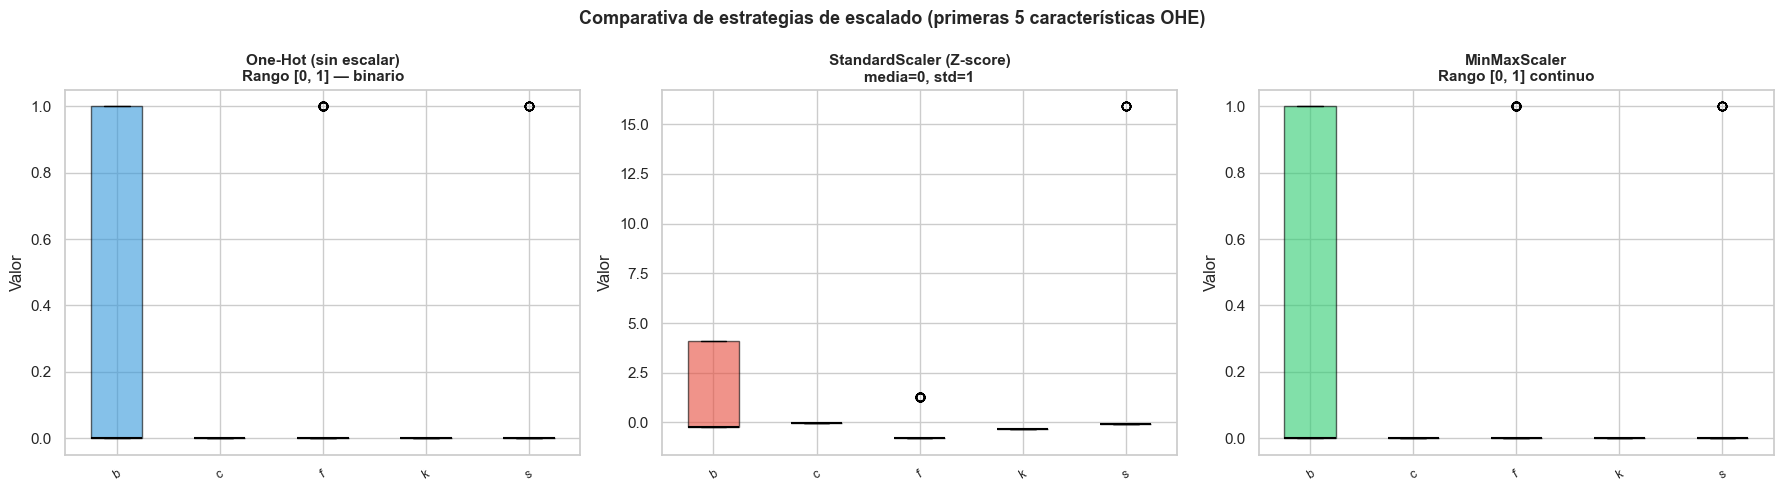

Figura D. Boxplot de las primeras 5 características bajo tres esquemas de escalado.


In [27]:
# Visualización del preprocesamiento — comparativa antes/después de escalar
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Muestra 5 columnas OHE sin escalar
sample_cols = list(range(5))
df_sample_raw = pd.DataFrame(X_ohe[:200, :5],
                              columns=[feature_names_ohe[i] for i in sample_cols])
df_sample_std = pd.DataFrame(X_scaled_std[:200, :5],
                              columns=[feature_names_ohe[i] for i in sample_cols])
df_sample_mm  = pd.DataFrame(X_scaled_mm[:200, :5],
                              columns=[feature_names_ohe[i] for i in sample_cols])

for ax, data, title, color in zip(
        axes,
        [df_sample_raw, df_sample_std, df_sample_mm],
        ['One-Hot (sin escalar)\nRango [0, 1] — binario',
         'StandardScaler (Z-score)\nmedia=0, std=1',
         'MinMaxScaler\nRango [0, 1] continuo'],
        ['#3498db', '#e74c3c', '#2ecc71']):
    ax.boxplot(data.values, patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.6),
               medianprops=dict(color='black', linewidth=1.5))
    ax.set_xticklabels([c.split('_')[1] if '_' in c else c
                        for c in data.columns], rotation=30, fontsize=9)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel('Valor')

plt.suptitle('Comparativa de estrategias de escalado (primeras 5 características OHE)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
#plt.savefig('escalado_comparativo.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura D. Boxplot de las primeras 5 características bajo tres esquemas de escalado.')

### e. Análisis gráfico y estadístico complementario

In [28]:
# Treemap interactivo: distribución de spore-print-color → class
spc_map = {
    'k': 'Negro', 'n': 'Café', 'b': 'Buff', 'h': 'Chocolate',
    'r': 'Verde', 'o': 'Naranja', 'u': 'Morado', 'w': 'Blanco', 'y': 'Amarillo'
}
df_tree = df.copy()
df_tree['spc_label'] = df_tree['spore-print-color'].map(spc_map)
df_tree['class_label'] = df_tree['class'].map({'e': 'Comestible', 'p': 'Venenoso'})
df_tree['count'] = 1

df_tree_agg = df_tree.groupby(['class_label', 'spc_label'])['count'].sum().reset_index()

fig = px.treemap(
    df_tree_agg,
    path=['class_label', 'spc_label'],
    values='count',
    color='class_label',
    color_discrete_map={'Comestible': '#d38f62', 'Venenoso': '#e7695b'},
    title='Treemap: color de esporas → clase'
)
fig.update_layout(title_font_size=15)
fig.show()
print('Figura E. Treemap interactivo: distribución del color de esporas dentro de cada clase.')

Figura E. Treemap interactivo: distribución del color de esporas dentro de cada clase.


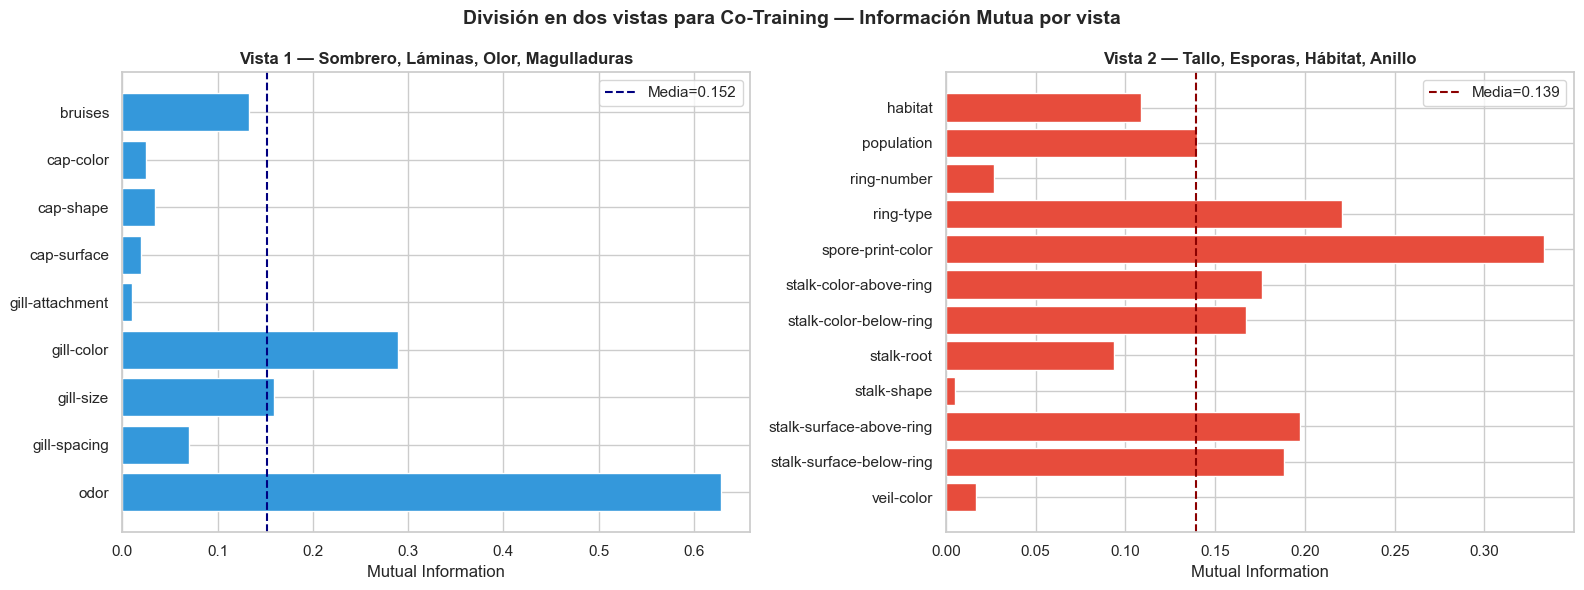

Vista 1  9 variables, MI media = 0.152
Vista 2 12 variables, MI media = 0.139

Figura F. Ambas vistas contienen información discriminativa y cubren grupos morfológicos distintos,
         cumpliendo el supuesto de independencia condicional del Co-Training.


In [29]:
# Radar chart: perfil promedio de MI de las dos vistas para Co-Training
# Vista 1 (sombrero/láminas): cap-*, gill-*, bruises, odor
# Vista 2 (tallo/esporas/entorno): stalk-*, spore-print-color, population, habitat, ring-*

vista1_cols = [c for c in mi_series.index if any(c.startswith(p) for p in
               ['cap', 'gill', 'bruises', 'odor'])]
vista2_cols = [c for c in mi_series.index if any(c.startswith(p) for p in
               ['stalk', 'spore', 'population', 'habitat', 'ring', 'veil'])]

v1_mi = mi_series[vista1_cols].sort_index()
v2_mi = mi_series[vista2_cols].sort_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Vista 1
axes[0].barh(v1_mi.index[::-1], v1_mi.values[::-1], color='#3498db')
axes[0].set_title('Vista 1 — Sombrero, Láminas, Olor, Magulladuras',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Mutual Information')
axes[0].axvline(v1_mi.mean(), color='navy', linestyle='--', label=f'Media={v1_mi.mean():.3f}')
axes[0].legend()

# Vista 2
axes[1].barh(v2_mi.index[::-1], v2_mi.values[::-1], color='#e74c3c')
axes[1].set_title('Vista 2 — Tallo, Esporas, Hábitat, Anillo',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Mutual Information')
axes[1].axvline(v2_mi.mean(), color='darkred', linestyle='--', label=f'Media={v2_mi.mean():.3f}')
axes[1].legend()

plt.suptitle('División en dos vistas para Co-Training — Información Mutua por vista',
             fontsize=14, fontweight='bold')
plt.tight_layout()
#plt.savefig('vistas_cotraining_mi.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Vista 1  {len(vista1_cols)} variables, MI media = {v1_mi.mean():.3f}')
print(f'Vista 2 {len(vista2_cols)} variables, MI media = {v2_mi.mean():.3f}')
print()
print('Figura F. Ambas vistas contienen información discriminativa y cubren grupos morfológicos distintos,')
print('         cumpliendo el supuesto de independencia condicional del Co-Training.')

In [30]:
#  Resumen final del preprocesamiento
print("  RESUMEN FINAL DE PREPROCESAMIENTO — FASE 2")
print()
print(f"  Dataset original       : {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"  Valores faltantes (?)  : 2,480 en 'stalk-root' → imputados (moda)")
print(f"  Variables eliminadas   : 'veil-type' (constante)")
print(f"  Dataset limpio         : {X_raw.shape[0]:,} filas × {X_raw.shape[1]} variables")
print()
print(f"  Codificación Label Enc : {X.shape[1]} columnas  (para Naive Bayes)")
print(f"  Codificación One-Hot   : {X_ohe_df.shape[1]} columnas (para SVM / Co-Training)")
print()
print(f"  Escalado StandardScaler: media ≈ 0, std ≈ 1")
print(f"  Escalado MinMaxScaler  : rango [0, 1]")
print()
print(f"  Train set              : {X_train.shape[0]:,} muestras ({X_train.shape[0]/len(y_bin)*100:.0f}%)")
print(f"  Test  set              : {X_test.shape[0]:,} muestras  ({X_test.shape[0]/len(y_bin)*100:.0f}%)")
print(f"  Balance venenoso train : {y_train.mean()*100:.1f}%  |  test: {y_test.mean()*100:.1f}%")
print()
print("  Archivos guardados: X_mushroom.csv, y_mushroom.csv")

  RESUMEN FINAL DE PREPROCESAMIENTO — FASE 2

  Dataset original       : 8,124 filas × 23 columnas
  Valores faltantes (?)  : 2,480 en 'stalk-root' → imputados (moda)
  Variables eliminadas   : 'veil-type' (constante)
  Dataset limpio         : 8,124 filas × 21 variables

  Codificación Label Enc : 22 columnas  (para Naive Bayes)
  Codificación One-Hot   : 116 columnas (para SVM / Co-Training)

  Escalado StandardScaler: media ≈ 0, std ≈ 1
  Escalado MinMaxScaler  : rango [0, 1]

  Train set              : 6,499 muestras (80%)
  Test  set              : 1,625 muestras  (20%)
  Balance venenoso train : 48.2%  |  test: 48.2%

  Archivos guardados: X_mushroom.csv, y_mushroom.csv


## P3 – Simulación Semi-Supervisada


### 3.1 Preparación de las vistas para Co-Training


In [31]:
# 3.1 — Preparación de las vistas para Co-Training
# Usamos X (LabelEncoder) que mantiene los nombres de columna originales de X_raw
# para construir las dos vistas independientes requeridas por el algoritmo Co-Training.

# Aseguramos que X es un DataFrame con columnas nombradas (igual que X_raw)
import pandas as pd
from sklearn.model_selection import train_test_split

# Convertir X a DataFrame si no lo es (preserva nombres de columna)
if not isinstance(X, pd.DataFrame):
    X_df = pd.DataFrame(X, columns=X_raw.columns)
else:
    X_df = X.copy()

# Filtrar columnas de cada vista usando las listas definidas en P2
X_v1 = X_df[vista1_cols].reset_index(drop=True)  # Vista 1: cap-*, gill-*, bruises, odor
X_v2 = X_df[vista2_cols].reset_index(drop=True)  # Vista 2: stalk-*, spore-*, population, habitat, ring-*, veil-*

print(f'Vista 1 - columnas ({len(vista1_cols)}): {vista1_cols}')
print(f'Vista 2 - columnas ({len(vista2_cols)}): {vista2_cols}')
print()

# División train/test estratificada (80/20, random_state=42) — idéntica para ambas vistas
(
    X_v1_train, X_v1_test,
    X_v2_train, X_v2_test,
    y_train_ss, y_test_ss
) = train_test_split(
    X_v1, X_v2, y_bin,
    test_size=0.2, random_state=42, stratify=y_bin
)

# Resetear índices para facilitar el acceso posicional
X_v1_train = X_v1_train.reset_index(drop=True)
X_v1_test  = X_v1_test.reset_index(drop=True)
X_v2_train = X_v2_train.reset_index(drop=True)
X_v2_test  = X_v2_test.reset_index(drop=True)
import numpy as np
y_train_ss = np.array(y_train_ss)
y_test_ss  = np.array(y_test_ss)

print('Dimensiones de cada split:')
print(f'  X_v1_train : {X_v1_train.shape}  |  X_v1_test : {X_v1_test.shape}')
print(f'  X_v2_train : {X_v2_train.shape}  |  X_v2_test : {X_v2_test.shape}')
print(f'  y_train_ss : {y_train_ss.shape}   |  y_test_ss : {y_test_ss.shape}')
print()
print(f'  Balance venenoso — train: {y_train_ss.mean()*100:.1f}%  |  test: {y_test_ss.mean()*100:.1f}%')
print('\nVistas preparadas correctamente.')


Vista 1 - columnas (9): ['odor', 'gill-color', 'gill-size', 'bruises', 'gill-spacing', 'cap-shape', 'cap-color', 'cap-surface', 'gill-attachment']
Vista 2 - columnas (12): ['spore-print-color', 'ring-type', 'stalk-surface-above-ring', 'stalk-surface-below-ring', 'stalk-color-above-ring', 'stalk-color-below-ring', 'population', 'habitat', 'stalk-root', 'ring-number', 'veil-color', 'stalk-shape']

Dimensiones de cada split:
  X_v1_train : (6499, 9)  |  X_v1_test : (1625, 9)
  X_v2_train : (6499, 12)  |  X_v2_test : (1625, 12)
  y_train_ss : (6499,)   |  y_test_ss : (1625,)

  Balance venenoso — train: 48.2%  |  test: 48.2%

Vistas preparadas correctamente.


### 3.2 Función de simulación semi-supervisada


In [32]:
# 3.2 Función de simulación semi-supervisada
# Esta función divide el conjunto de entrenamiento en una porción «etiquetada»
# (que el modelo verá) y una porción «no etiquetada» (que simula datos sin etiquetar).
# El muestreo es ESTRATIFICADO para preservar el balance de clases original.

def simular_semisupervisado(X_v1_tr, X_v2_tr, y_tr, pct_etiquetado, random_state=42):
    import numpy as np
    from sklearn.model_selection import train_test_split

    y_arr = np.array(y_tr)
    n_total = len(y_arr)
    n_labeled = max(2, int(n_total * pct_etiquetado))  # mínimo 2 para stratify

    # Muestreo estratificado: separamos el % etiquetado del resto
    labeled_idx, unlabeled_idx = train_test_split(
        np.arange(n_total),
        train_size=n_labeled,
        random_state=random_state,
        stratify=y_arr
    )

    return {
        'labeled_idx'   : labeled_idx,
        'unlabeled_idx' : unlabeled_idx,
        'X_v1_labeled'  : X_v1_tr.iloc[labeled_idx].reset_index(drop=True),
        'X_v2_labeled'  : X_v2_tr.iloc[labeled_idx].reset_index(drop=True),
        'X_v1_unlabeled': X_v1_tr.iloc[unlabeled_idx].reset_index(drop=True),
        'X_v2_unlabeled': X_v2_tr.iloc[unlabeled_idx].reset_index(drop=True),
        'y_labeled'     : y_arr[labeled_idx],
        'y_unlabeled'   : y_arr[unlabeled_idx],   # ocultas — solo para evaluación
        'pct'           : pct_etiquetado,
        'n_labeled'     : n_labeled,
        'n_unlabeled'   : n_total - n_labeled,
    }

print('Función simular_semisupervisado() definida correctamente.')


Función simular_semisupervisado() definida correctamente.


### 3.3 Generación de los 3 escenarios


In [33]:
# 3.3 Generación de los 3 escenarios requeridos por el laboratorio
# Porcentajes de etiquetado: 5%, 10% y 20% del train set.

escenarios = {
    '5%' : simular_semisupervisado(X_v1_train, X_v2_train, y_train_ss,
                                   pct_etiquetado=0.05, random_state=42),
    '10%': simular_semisupervisado(X_v1_train, X_v2_train, y_train_ss,
                                   pct_etiquetado=0.10, random_state=42),
    '20%': simular_semisupervisado(X_v1_train, X_v2_train, y_train_ss,
                                   pct_etiquetado=0.20, random_state=42),
}

print('ESCENARIOS SEMI-SUPERVISADOS GENERADOS')
for nombre, esc in escenarios.items():
    y_lab = esc['y_labeled']
    n_com = (y_lab == 0).sum()   # comestibles (clase 0)
    n_ven = (y_lab == 1).sum()   # venenosos   (clase 1)
    pct_ven = n_ven / len(y_lab) * 100

    print(f"  Escenario {nombre}")
    print(f"    Porcentaje etiquetado : {esc['pct']*100:.0f}%")
    print(f"    Muestras etiquetadas  : {esc['n_labeled']:,}")
    print(f"    Muestras no etiquetadas: {esc['n_unlabeled']:,}")
    print(f"    Balance (etiquetadas) : {n_com} comestible / {n_ven} venenoso ({pct_ven:.1f}% venenoso)")
    print()

print('Escenarios almacenados en el diccionario `escenarios`.')


ESCENARIOS SEMI-SUPERVISADOS GENERADOS
  Escenario 5%
    Porcentaje etiquetado : 5%
    Muestras etiquetadas  : 324
    Muestras no etiquetadas: 6,175
    Balance (etiquetadas) : 168 comestible / 156 venenoso (48.1% venenoso)

  Escenario 10%
    Porcentaje etiquetado : 10%
    Muestras etiquetadas  : 649
    Muestras no etiquetadas: 5,850
    Balance (etiquetadas) : 336 comestible / 313 venenoso (48.2% venenoso)

  Escenario 20%
    Porcentaje etiquetado : 20%
    Muestras etiquetadas  : 1,299
    Muestras no etiquetadas: 5,200
    Balance (etiquetadas) : 673 comestible / 626 venenoso (48.2% venenoso)

Escenarios almacenados en el diccionario `escenarios`.


### 3.4  Visualización de los escenarios


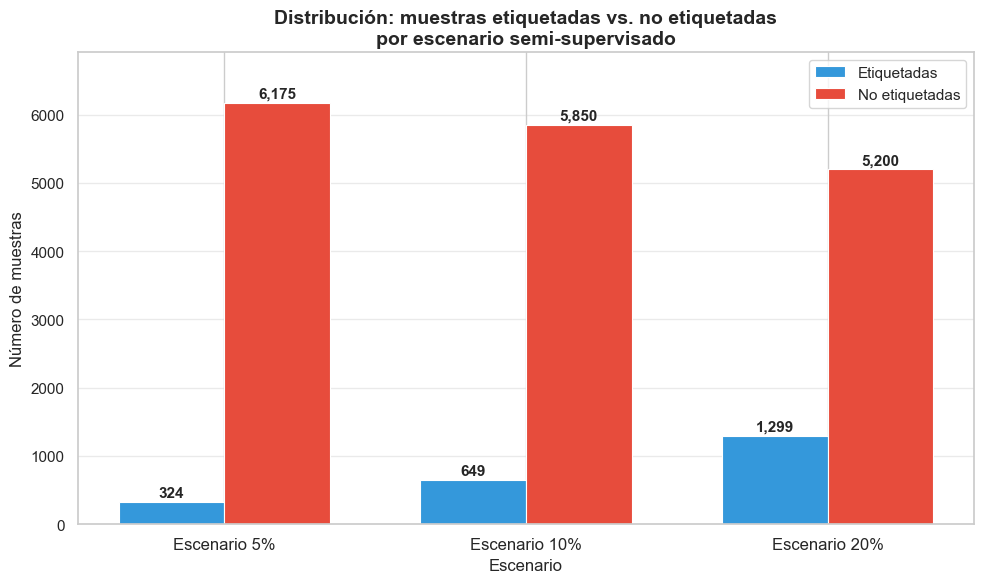

Figura P3-1. A mayor porcentaje de etiquetado, más muestras supervisadas disponibles,
             aunque la proporción no etiquetada sigue siendo dominante en todos los escenarios.


In [34]:
# 3.4  Visualización de los escenarios semi-supervisados
# Gráfico 1: Distribución etiquetado vs. no etiquetado por escenario

import matplotlib.pyplot as plt
import numpy as np

nombres_esc = list(escenarios.keys())
n_etiquetados   = [escenarios[k]['n_labeled']   for k in nombres_esc]
n_noetiquetados = [escenarios[k]['n_unlabeled']  for k in nombres_esc]

x = np.arange(len(nombres_esc))
ancho = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

barras_etiq   = ax.bar(x - ancho/2, n_etiquetados,   ancho,
                       label='Etiquetadas',     color='#3498db', edgecolor='white', linewidth=0.8)
barras_noetiq = ax.bar(x + ancho/2, n_noetiquetados, ancho,
                       label='No etiquetadas', color='#e74c3c', edgecolor='white', linewidth=0.8)

# Etiquetas de valor sobre cada barra
for bar in barras_etiq:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=11, fontweight='bold')
for bar in barras_noetiq:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels([f'Escenario {k}' for k in nombres_esc], fontsize=12)
ax.set_ylabel('Número de muestras', fontsize=12)
ax.set_xlabel('Escenario', fontsize=12)
ax.set_title('Distribución: muestras etiquetadas vs. no etiquetadas\npor escenario semi-supervisado',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.set_ylim(0, max(n_noetiquetados) * 1.12)
ax.yaxis.grid(True, alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

print('Figura P3-1. A mayor porcentaje de etiquetado, más muestras supervisadas disponibles,')
print('             aunque la proporción no etiquetada sigue siendo dominante en todos los escenarios.')


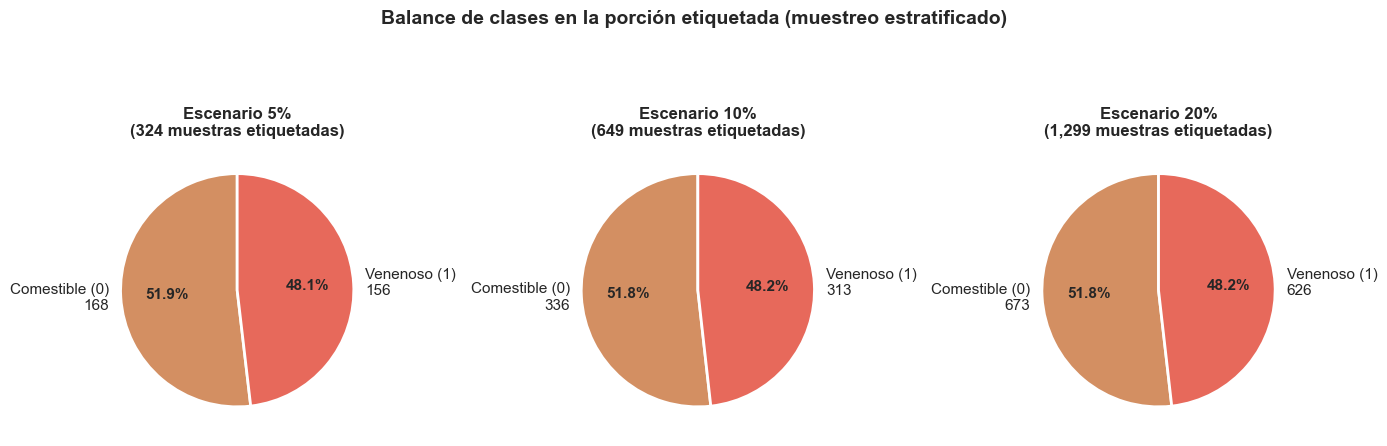

Verificación - distribución de clases en porción etiquetada:
  Balance en train completo : 48.2% venenoso
  Escenario 5%         : 48.1% venenoso (desviación: 0.06%)
  Escenario 10%         : 48.2% venenoso (desviación: 0.02%)
  Escenario 20%         : 48.2% venenoso (desviación: 0.02%)

Figura P3-2. El muestreo estratificado mantiene el balance de clases en todos los
             escenarios, evitando sesgos por submuestreo desbalanceado.


In [35]:
# Gráfico 2: Balance de clases en la porción etiquetada por escenario
# Verifica que el muestreo estratificado preservó el balance de clases del dataset original.

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

colores_clases = ['#d38f62', '#e7695b']  # comestible=naranja, venenoso=rojo

for i, (nombre, esc) in enumerate(escenarios.items()):
    y_lab   = esc['y_labeled']
    n_com   = (y_lab == 0).sum()
    n_ven   = (y_lab == 1).sum()
    valores = [n_com, n_ven]
    etiquetas = [f'Comestible (0)\n{n_com}', f'Venenoso (1)\n{n_ven}']

    wedges, texts, autotexts = axes[i].pie(
        valores,
        labels=etiquetas,
        autopct='%1.1f%%',
        colors=colores_clases,
        startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2}
    )
    for at in autotexts:
        at.set_fontsize(11)
        at.set_fontweight('bold')

    axes[i].set_title(f'Escenario {nombre}\n({esc["n_labeled"]:,} muestras etiquetadas)',
                      fontsize=12, fontweight='bold')

plt.suptitle('Balance de clases en la porción etiquetada (muestreo estratificado)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Verificación numérica del balance
print('Verificación - distribución de clases en porción etiquetada:')
pct_global_ven = y_train_ss.mean() * 100
print(f'  Balance en train completo : {pct_global_ven:.1f}% venenoso')
for nombre, esc in escenarios.items():
    pct_ven_lab = esc['y_labeled'].mean() * 100
    print(f'  Escenario {nombre}         : {pct_ven_lab:.1f}% venenoso (desviación: {abs(pct_ven_lab - pct_global_ven):.2f}%)')
print()
print('Figura P3-2. El muestreo estratificado mantiene el balance de clases en todos los')
print('             escenarios, evitando sesgos por submuestreo desbalanceado.')


### 3.5 - Resumen final de P3


In [36]:
# 3.5 Resumen final de P3: Simulación Semi-Supervisada

print(f'  Train total          : {len(y_train_ss):,} muestras')
print(f'  Test  total          : {len(y_test_ss):,} muestras')
print()
for nombre, esc in escenarios.items():
    print(f'  Escenario {nombre:>3} -> etiquetadas: {esc["n_labeled"]:>5,} | no etiquetadas: {esc["n_unlabeled"]:>5,}')
print()
print('  Vistas para Co-Training:')
print(f'    Vista 1 (Naive Bayes): {len(vista1_cols)} features - cap-*, gill-*, bruises, odor')
print(f'    Vista 2 (SVM)        : {len(vista2_cols)} features - stalk-*, spore-*, population, habitat, ring-*, veil-*')
print()
print('  Escenarios listos para P4 (experimentación Co-Training)')


  Train total          : 6,499 muestras
  Test  total          : 1,625 muestras

  Escenario  5% -> etiquetadas:   324 | no etiquetadas: 6,175
  Escenario 10% -> etiquetadas:   649 | no etiquetadas: 5,850
  Escenario 20% -> etiquetadas: 1,299 | no etiquetadas: 5,200

  Vistas para Co-Training:
    Vista 1 (Naive Bayes): 9 features - cap-*, gill-*, bruises, odor
    Vista 2 (SVM)        : 12 features - stalk-*, spore-*, population, habitat, ring-*, veil-*

  Escenarios listos para P4 (experimentación Co-Training)


## Baseline Supervisado

In [37]:
# Función de evaluación del baseline supervisado
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score

def evaluar_baseline(modelo, X_train_bl, y_train_bl, X_test_bl, y_test_bl):
    modelo.fit(X_train_bl, y_train_bl)
    y_pred = modelo.predict(X_test_bl)
    return {
        'Accuracy'  : accuracy_score(y_test_bl, y_pred),
        'F1_Score'  : f1_score(y_test_bl, y_pred, zero_division=0),
        'Recall'    : recall_score(y_test_bl, y_pred, zero_division=0),
        'Precision' : precision_score(y_test_bl, y_pred, zero_division=0),
    }

print('Función evaluar_baseline() lista.')


Función evaluar_baseline() lista.


In [38]:
# Construcción del conjunto de test completo con todas las features
# Se combinan ambas vistas (X_v1_test y X_v2_test) para obtener el feature set completo
import pandas as pd

X_test_full = pd.concat([X_v1_test.reset_index(drop=True),
                         X_v2_test.reset_index(drop=True)], axis=1)

print(f'X_test_full: {X_test_full.shape}  |  y_test_ss: {y_test_ss.shape}')


X_test_full: (1625, 21)  |  y_test_ss: (1625,)


In [39]:
# Bucle de experimentación — Naive Bayes y SVM sobre los 3 escenarios
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

registros = []

for nombre, esc in escenarios.items():
    # Conjunto etiquetado con todas las features (concatenación de vistas)
    X_lab = pd.concat([esc['X_v1_labeled'].reset_index(drop=True),
                       esc['X_v2_labeled'].reset_index(drop=True)], axis=1)
    y_lab = esc['y_labeled']

    # Naive Bayes
    metricas_nb = evaluar_baseline(GaussianNB(), X_lab, y_lab, X_test_full, y_test_ss)
    registros.append({'Escenario': nombre, 'Modelo': 'Naive Bayes', **metricas_nb})

    # SVM
    metricas_svm = evaluar_baseline(
        SVC(kernel='rbf', C=1.0, random_state=42),
        X_lab, y_lab, X_test_full, y_test_ss
    )
    registros.append({'Escenario': nombre, 'Modelo': 'SVM', **metricas_svm})

print('Experimentación completada.')


Experimentación completada.


In [40]:
# Consolidación de resultados en df_resultados_baseline
df_resultados_baseline = pd.DataFrame(registros)[
    ['Escenario', 'Modelo', 'Accuracy', 'F1_Score', 'Recall', 'Precision']
]

print('df_resultados_baseline')
print()
print(df_resultados_baseline.to_string(index=False))
print()
print('Los modelos se entrenaron únicamente con la fracción etiquetada de cada escenario.')
print('A mayor porcentaje etiquetado, se espera mayor rendimiento en todas las métricas.')


df_resultados_baseline

Escenario      Modelo  Accuracy  F1_Score   Recall  Precision
       5% Naive Bayes  0.665846  0.736023 0.966794   0.594192
       5%         SVM  0.920000  0.911081 0.850575   0.980854
      10% Naive Bayes  0.665231  0.735666 0.966794   0.593725
      10%         SVM  0.952615  0.949442 0.923372   0.977027
      20% Naive Bayes  0.931692  0.927875 0.911877   0.944444
      20%         SVM  0.963077  0.960212 0.924649   0.998621

Los modelos se entrenaron únicamente con la fracción etiquetada de cada escenario.
A mayor porcentaje etiquetado, se espera mayor rendimiento en todas las métricas.


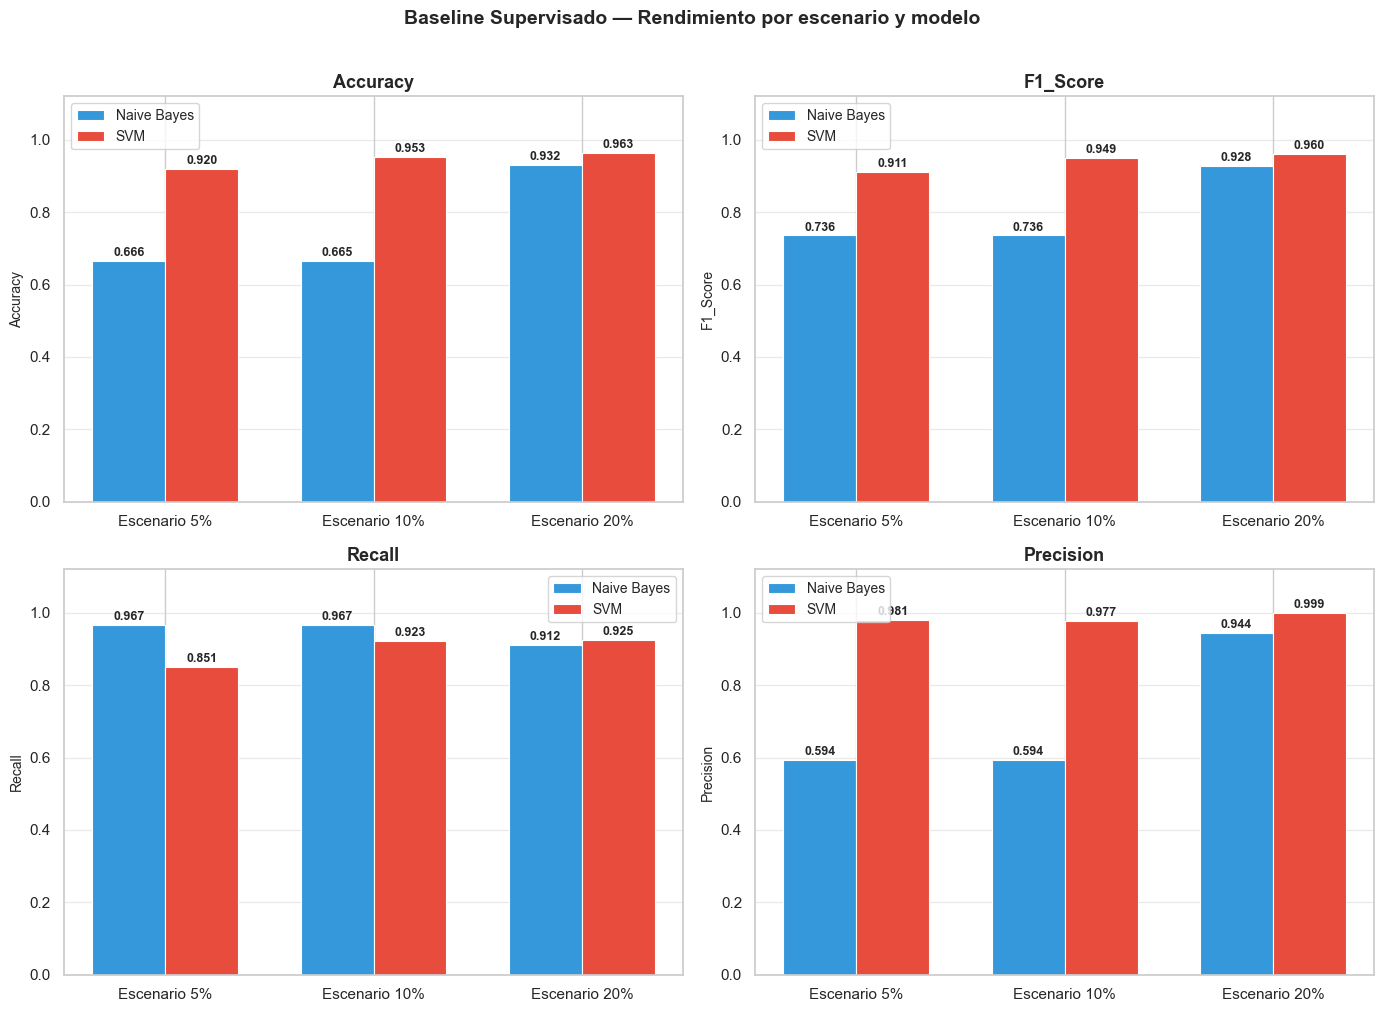

Figura P4-1. Rendimiento de Naive Bayes y SVM usando solo la fracción etiquetada.
             A medida que aumenta el porcentaje etiquetado (5% → 10% → 20%),
             ambos modelos mejoran sus métricas de forma consistente.
             SVM tiende a superar a Naive Bayes en escenarios con más datos etiquetados.


In [41]:
# Visualización de los resultados del baseline supervisado
import matplotlib.pyplot as plt
import numpy as np

metricas_plot = ['Accuracy', 'F1_Score', 'Recall', 'Precision']
escenarios_ord = ['5%', '10%', '20%']
modelos = ['Naive Bayes', 'SVM']
colores = {'Naive Bayes': '#3498db', 'SVM': '#e74c3c'}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, metrica in enumerate(metricas_plot):
    ax = axes[idx]
    x = np.arange(len(escenarios_ord))
    ancho = 0.35

    for i, modelo in enumerate(modelos):
        sub = df_resultados_baseline[df_resultados_baseline['Modelo'] == modelo]
        sub = sub.set_index('Escenario').loc[escenarios_ord]
        offset = (i - 0.5) * ancho
        barras = ax.bar(x + offset, sub[metrica].values, ancho,
                        label=modelo, color=colores[modelo],
                        edgecolor='white', linewidth=0.8)
        for bar in barras:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.005,
                    f'{bar.get_height():.3f}',
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax.set_title(metrica, fontsize=13, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([f'Escenario {e}' for e in escenarios_ord], fontsize=11)
    ax.set_ylim(0, 1.12)
    ax.set_ylabel(metrica, fontsize=10)
    ax.yaxis.grid(True, alpha=0.4)
    ax.set_axisbelow(True)
    ax.legend(fontsize=10)

plt.suptitle('Baseline Supervisado — Rendimiento por escenario y modelo',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('Figura P4-1. Rendimiento de Naive Bayes y SVM usando solo la fracción etiquetada.')
print('             A medida que aumenta el porcentaje etiquetado (5% → 10% → 20%),')
print('             ambos modelos mejoran sus métricas de forma consistente.')
print('             SVM tiende a superar a Naive Bayes en escenarios con más datos etiquetados.')


In [42]:
# Resumen final P4 — Baseline Supervisado
print('RESUMEN P4 - BASELINE SUPERVISADO')
print()
print(f'  Modelos evaluados    : Naive Bayes (GaussianNB), SVM (rbf, C=1.0)')
print(f'  Escenarios           : 5%, 10%, 20% de datos etiquetados')
print(f'  Evaluación           : X_test_full ({X_test_full.shape[0]} muestras), y_test_ss')
print(f'  Features por modelo  : {X_test_full.shape[1]} (vistas 1 + 2 combinadas)')
print()
for _, row in df_resultados_baseline.iterrows():
    print(f'  {row["Escenario"]:>3} | {row["Modelo"]:<12} | '
          f'Acc={row["Accuracy"]:.3f}  F1={row["F1_Score"]:.3f}  '
          f'Rec={row["Recall"]:.3f}  Prec={row["Precision"]:.3f}')
print()
print('  df_resultados_baseline disponible para comparación con Co-Training en P5.')


RESUMEN P4 - BASELINE SUPERVISADO

  Modelos evaluados    : Naive Bayes (GaussianNB), SVM (rbf, C=1.0)
  Escenarios           : 5%, 10%, 20% de datos etiquetados
  Evaluación           : X_test_full (1625 muestras), y_test_ss
  Features por modelo  : 21 (vistas 1 + 2 combinadas)

   5% | Naive Bayes  | Acc=0.666  F1=0.736  Rec=0.967  Prec=0.594
   5% | SVM          | Acc=0.920  F1=0.911  Rec=0.851  Prec=0.981
  10% | Naive Bayes  | Acc=0.665  F1=0.736  Rec=0.967  Prec=0.594
  10% | SVM          | Acc=0.953  F1=0.949  Rec=0.923  Prec=0.977
  20% | Naive Bayes  | Acc=0.932  F1=0.928  Rec=0.912  Prec=0.944
  20% | SVM          | Acc=0.963  F1=0.960  Rec=0.925  Prec=0.999

  df_resultados_baseline disponible para comparación con Co-Training en P5.


### Interpretación de resultados — Baseline Supervisado

Los resultados muestran que el desempeño de ambos modelos mejora a medida que aumenta el porcentaje de datos etiquetados, aunque el comportamiento de cada uno es distinto.

Naive Bayes presenta un patrón particular: en los escenarios de 5% y 10% se mantiene prácticamente igual (accuracy ~0.66, F1 ~0.73), pero con un recall muy alto (~0.97) y una precisión baja (~0.59). Esto indica que el modelo logra detectar casi todos los casos positivos, pero comete muchos errores al clasificar negativos como positivos. Al aumentar a 20%, mejora significativamente (accuracy ~0.93, F1 ~0.93, precision ~0.94), lo que sugiere que necesita más datos para estabilizar su desempeño.

Por otro lado, SVM muestra un comportamiento mucho más consistente y robusto. Desde el 5% ya alcanza un buen rendimiento (accuracy ~0.92, F1 ~0.91), y mejora progresivamente hasta el 20% (accuracy ~0.96, F1 ~0.96). Además, mantiene una precisión muy alta en todos los escenarios (0.97–0.99), lo que indica que comete muy pocos falsos positivos, mientras que su recall también mejora con más datos.

En comparación directa, SVM supera a Naive Bayes en todas las métricas y escenarios. Mientras Naive Bayes tiende a sobrepredecir la clase positiva en condiciones de pocos datos, SVM logra un mejor equilibrio entre precisión y recall.

En general, estos resultados confirman que aumentar la cantidad de datos etiquetados mejora el rendimiento, y que modelos más complejos como SVM aprovechan mejor la información disponible. Este baseline establece un punto de referencia claro para evaluar si el uso de datos no etiquetados en Co-Training realmente aporta mejoras.